# Instagram Data Analysis

### Understanding User Engagement and Content Performance on Instagram

## Objectives

- Analyze user posting activity and engagement using likes and comments.
- Identify popular hashtags, filters, and content types based on user interactions.
- Recommend an effective content strategy and posting schedule for Alfido Tech.

In [680]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Loading the Dataset

The Instagram dataset consists of multiple CSV files containing information about users, photos, likes, comments, hashtags, and follower relationships. These datasets are loaded into Pandas DataFrames for further analysis.

In [681]:
comments = pd.read_csv("comments.csv")
photos = pd.read_csv("photos.csv")
users = pd.read_csv("users.csv")
likes = pd.read_csv("likes.csv")
follows = pd.read_csv("follows.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")

## Exploring the Dataset

The first few rows of each dataset are displayed to understand the structure, available columns, and sample records before performing analysis.

In [682]:
users.head()

,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no


In [683]:
photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


In [684]:
likes.head()

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


In [685]:
comments.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [686]:
tags.head()

,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


In [687]:
photo_tags.head()

,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


In [688]:
follows.head()

,follower,followee,created time,is follower active,followee Acc status
0,2,1,13-04-2023 08:04,1,Private
1,2,3,13-04-2023 08:04,0,private
2,2,4,13-04-2023 08:04,0,public
3,2,5,13-04-2023 08:04,0,private
4,2,6,13-04-2023 08:04,1,private


## Dataset Information

This section provides an overview of each dataset, including the number of rows, columns, and basic information required for analysis.

In [689]:
dataset_info = pd.DataFrame({
    "Dataset": [
        "Users",
        "Photos",
        "Likes",
        "Comments",
        "Follows",
        "Tags",
        "Photo Tags"
    ],

    "Rows": [
        users.shape[0],
        photos.shape[0],
        likes.shape[0],
        comments.shape[0],
        follows.shape[0],
        tags.shape[0],
        photo_tags.shape[0]
    ],

    "Columns": [
        users.shape[1],
        photos.shape[1],
        likes.shape[1],
        comments.shape[1],
        follows.shape[1],
        tags.shape[1],
        photo_tags.shape[1]
    ]
})

dataset_info

,Dataset,Rows,Columns
0,Users,100,6
1,Photos,257,6
2,Likes,8782,5
3,Comments,7488,8
4,Follows,7623,5
5,Tags,21,4
6,Photo Tags,501,3


In [690]:
users.columns

Index(['id', 'name', 'created time', 'private/public', 'post count',
       'Verified status'],
      dtype='object')

In [691]:
photos.columns

Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')

In [692]:
likes.columns

Index(['user ', 'photo', 'created time', 'following or not', 'like type'], dtype='object')

In [693]:
comments.columns

Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='object')

In [694]:
tags.columns

Index(['id', 'tag text', 'created time', 'location'], dtype='object')

In [695]:
photo_tags.columns

Index(['photo', 'tag ID', 'user id'], dtype='object')

In [696]:
follows.columns

Index(['follower', 'followee ', 'created time', 'is follower active',
       'followee Acc status'],
      dtype='object')

## Missing Value Analysis

Before performing analysis, each dataset is checked for missing values to ensure data quality and identify any preprocessing requirements.

In [697]:
users.isnull().sum().to_frame(name="Missing Values")

,Missing Values
id,0
name,0
created time,0
private/public,0
post count,0
Verified status,0


In [698]:
photos.isnull().sum().to_frame(name="Missing Values")

,Missing Values
id,0
image link,0
user ID,0
created dat,0
Insta filter used,0
photo type,0


In [699]:
likes.isnull().sum().to_frame(name="Missing Values")

,Missing Values
user,0
photo,0
created time,0
following or not,0
like type,0


In [700]:
comments.isnull().sum().to_frame(name="Missing Values")

,Missing Values
id,0
comment,0
User id,0
Photo id,0
created Timestamp,0
posted date,0
emoji used,0
Hashtags used count,0


In [701]:
tags.isnull().sum().to_frame(name="Missing Values")

,Missing Values
id,0
tag text,0
created time,0
location,0


In [702]:
photo_tags.isnull().sum().to_frame(name="Missing Values")

,Missing Values
photo,0
tag ID,0
user id,0


In [703]:
follows.isnull().sum().to_frame(name="Missing Values")

,Missing Values
follower,0
followee,0
created time,0
is follower active,0
followee Acc status,0


## Data Preprocessing

The date columns are converted into datetime format, and additional features such as posting year, month, and day are created to support time-based analysis.

In [704]:
photos["created dat"] = pd.to_datetime(
    photos["created dat"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

comments["posted date"] = pd.to_datetime(
    comments["posted date"],
    errors="coerce"
)

photos[["created dat"]].head()

,created dat
0,2023-04-13 08:04:00
1,2023-04-13 08:04:00
2,2023-04-13 08:04:00
3,2023-04-13 08:04:00
4,2023-04-13 08:04:00


In [705]:
photos = photos.assign(
    Posting_Year=photos["created dat"].dt.year,
    Posting_Month=photos["created dat"].dt.month_name(),
    Posting_Day=photos["created dat"].dt.day
)

photos[["Posting_Year", "Posting_Month", "Posting_Day"]].head()

,Posting_Year,Posting_Month,Posting_Day
0,2023,April,13
1,2023,April,13
2,2023,April,13
3,2023,April,13
4,2023,April,13


## User Posting Activity

This section analyzes the number of posts uploaded by each Instagram user to identify user activity and posting behavior.

In [706]:
user_posts = photos.groupby("user ID").size().reset_index(name="Total Posts")

user_posts.head()

,user ID,Total Posts
0,1,5
1,2,4
2,3,4
3,4,3
4,6,5


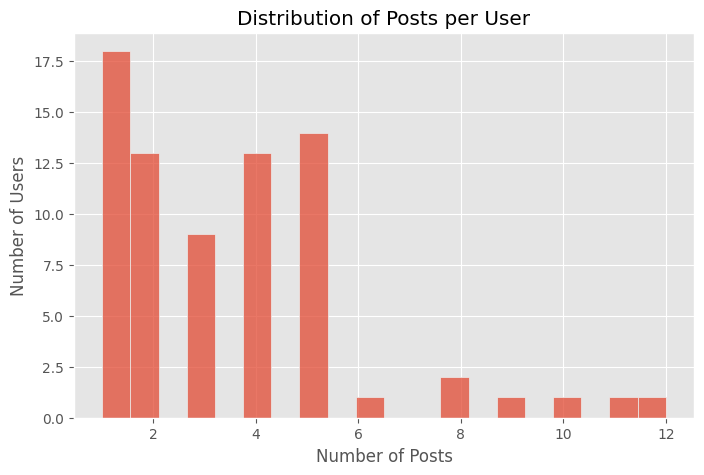

In [707]:
plt.figure(figsize=(8,5))

sns.histplot(user_posts["Total Posts"], bins=20)

plt.title("Distribution of Posts per User")
plt.xlabel("Number of Posts")
plt.ylabel("Number of Users")

plt.show()

## Most Active Instagram Users

The following visualization highlights the users with the highest number of uploaded posts.

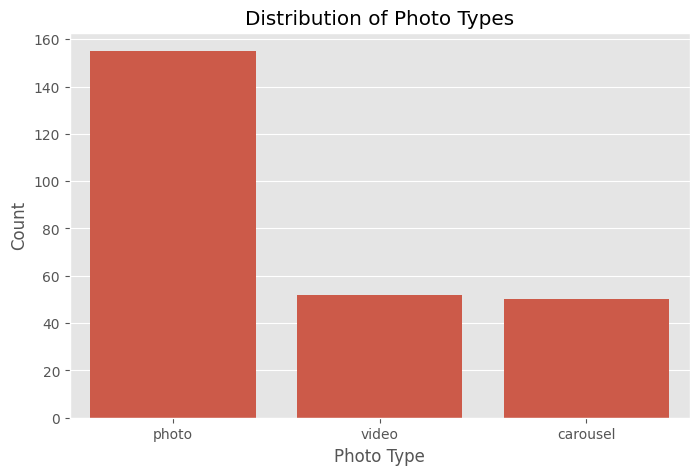

In [708]:
plt.figure(figsize=(8,5))

sns.countplot(data=photos, x="photo type")

plt.title("Distribution of Photo Types")
plt.xlabel("Photo Type")
plt.ylabel("Count")

plt.show()

## Photo Type Distribution

This analysis examines the distribution of different photo types uploaded by Instagram users.

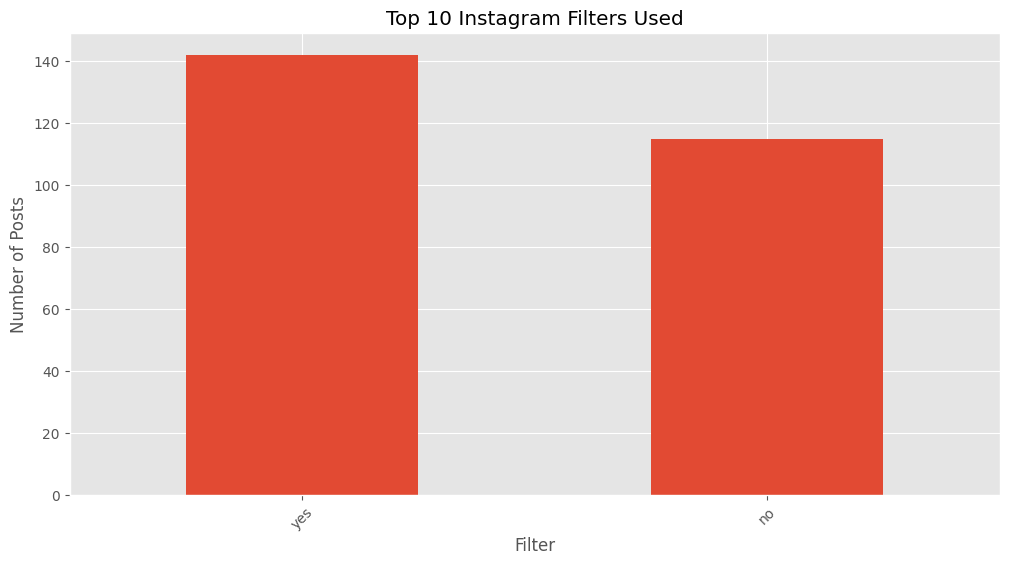

In [709]:
plt.figure(figsize=(12,6))

photos["Insta filter used"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Instagram Filters Used")
plt.xlabel("Filter")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.show()

## Likes Analysis

Likes indicate the popularity and engagement level of a post. This section identifies the photos receiving the highest number of likes.

In [710]:
likes_per_photo = likes.groupby("photo").size().reset_index(name="Likes")

likes_per_photo.head()

,photo,Likes
0,1,25
1,2,36
2,3,38
3,4,38
4,5,31


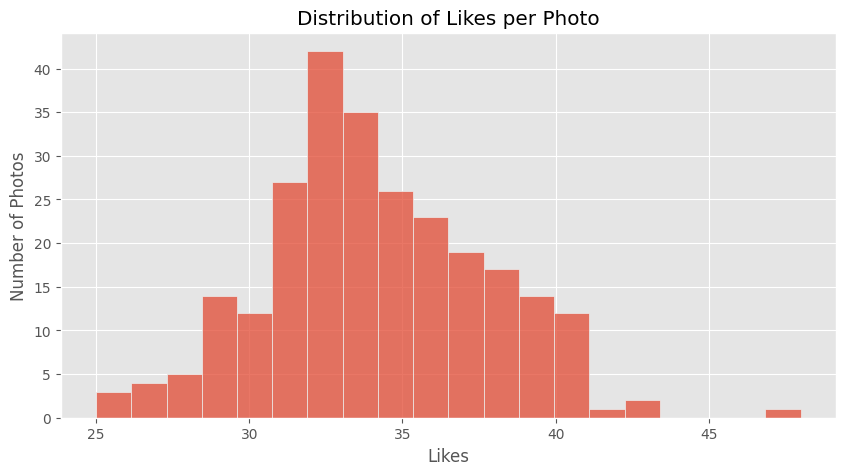

In [711]:
plt.figure(figsize=(10,5))

sns.histplot(likes_per_photo["Likes"], bins=20)

plt.title("Distribution of Likes per Photo")
plt.xlabel("Likes")
plt.ylabel("Number of Photos")

plt.show()

## Comments Analysis

Comments represent direct interaction between users and posts. This section analyzes the photos that generated the highest number of comments.

In [712]:
comments_per_photo = comments.groupby("Photo id").size().reset_index(name="Comments")

comments_per_photo.head()

,Photo id,Comments
0,1,25
1,2,31
2,3,27
3,4,32
4,5,27


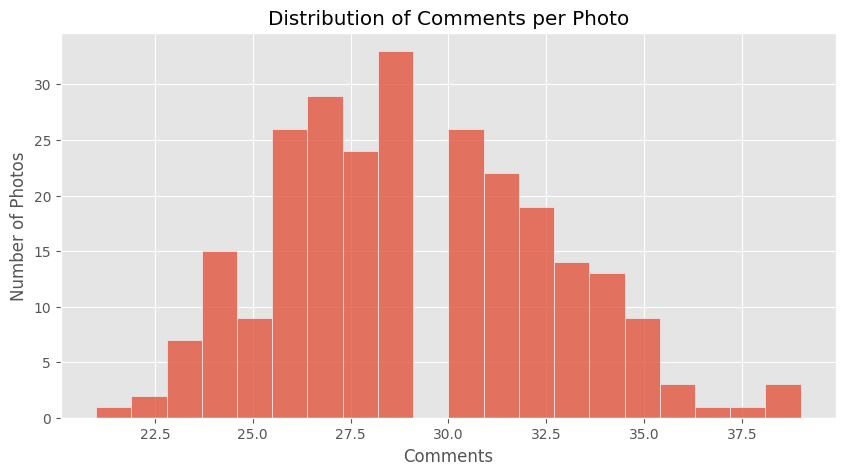

In [713]:
plt.figure(figsize=(10,5))

sns.histplot(comments_per_photo["Comments"], bins=20)

plt.title("Distribution of Comments per Photo")
plt.xlabel("Comments")
plt.ylabel("Number of Photos")

plt.show()

## Hashtag Analysis

Hashtags improve the visibility of Instagram posts. This section identifies the hashtags that appear most frequently in the dataset.

In [714]:
top_tags = tags["tag text"].value_counts().head(10)

top_tags

,count
tag text,
sunset,1
photography,1
sunrise,1
landscape,1
food,1
foodie,1
delicious,1
beauty,1
stunning,1


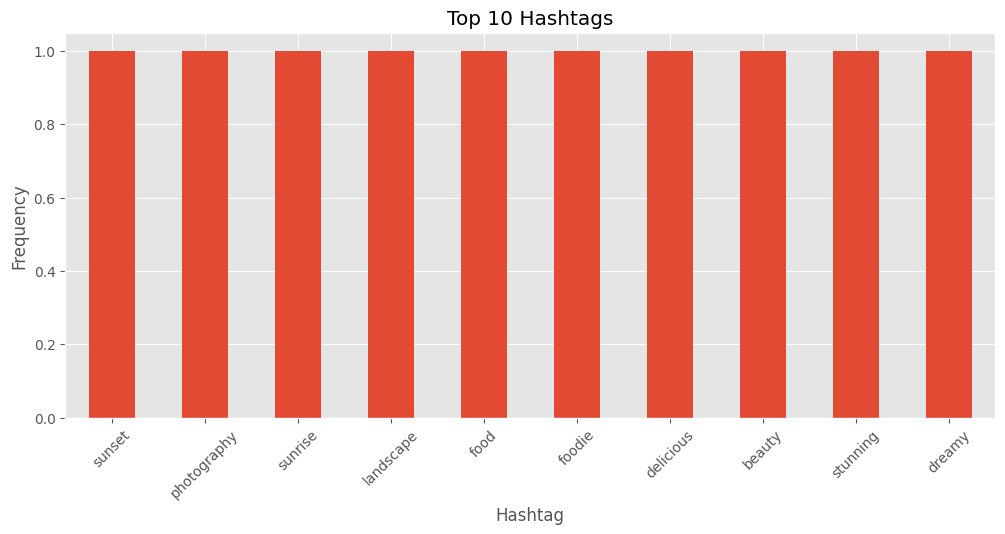

In [715]:
plt.figure(figsize=(12,5))

top_tags.plot(kind="bar")

plt.title("Top 10 Hashtags")
plt.xlabel("Hashtag")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## Posting Schedule Analysis

Monthly posting activity is analyzed to identify the periods with the highest number of uploaded posts.

In [716]:
user_post_count = (
    photos.groupby("user ID")
    .size()
    .reset_index(name="Total Posts")
)

user_post_count.head(10)

,user ID,Total Posts
0,1,5
1,2,4
2,3,4
3,4,3
4,6,5
5,8,4
6,9,4
7,10,3
8,11,5
9,12,4


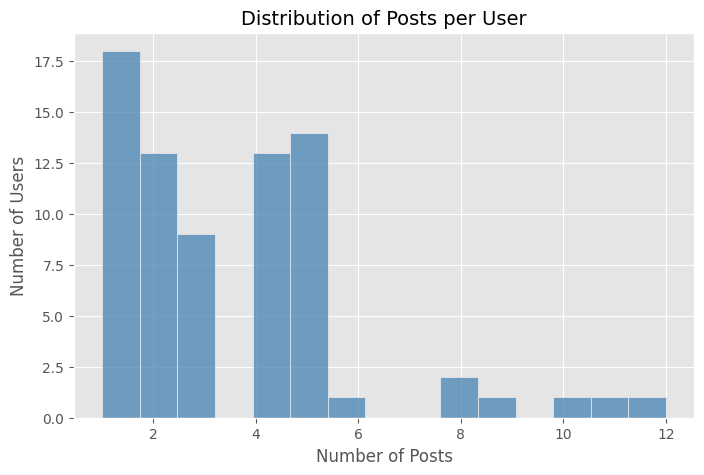

In [717]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_post_count,
    x="Total Posts",
    bins=15,
    color="steelblue"
)

plt.title("Distribution of Posts per User", fontsize=14)
plt.xlabel("Number of Posts")
plt.ylabel("Number of Users")

plt.show()

In [718]:
top_users = (
    users.merge(user_post_count, left_on="id", right_on="user ID")
    .sort_values(by="Total Posts", ascending=False)
)

top_users[["name", "Total Posts"]].head(10)

,name,Total Posts
18,Eveline95,12
64,Clint27,11
44,Cesar93,10
62,Delfina_VonRueden68,9
22,Jaime53,8
43,Aurelie71,8
56,Donald.Fritsch,6
8,Justina.Gaylord27,5
0,Kenton_Kirlin,5
4,Travon.Waters,5


## Photo Type Distribution

The distribution of photo types uploaded by users is visualized to understand content preferences.

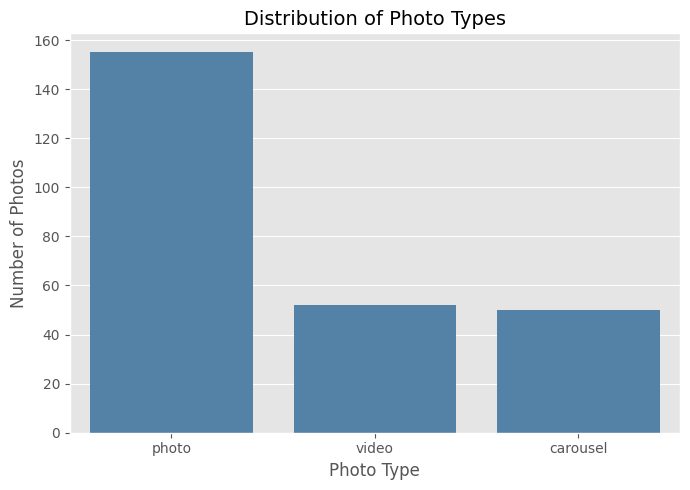

In [719]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=photos,
    x="photo type",
    color="steelblue"
)

plt.title("Distribution of Photo Types", fontsize=14)
plt.xlabel("Photo Type")
plt.ylabel("Number of Photos")

plt.tight_layout()
plt.show()

In [720]:
top_filters = (
    photos["Insta filter used"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_filters.columns = ["Filter", "Posts"]

top_filters

,Filter,Posts
0,yes,142
1,no,115


## Instagram Filter Usage

This section identifies the Instagram filters most frequently used by users.

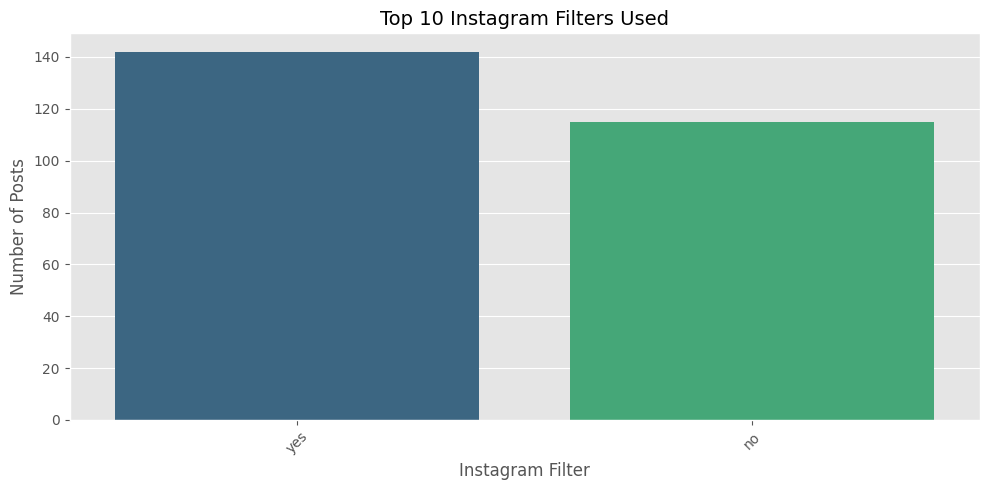

In [721]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_filters,
    x="Filter",
    y="Posts",
    hue="Filter",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Instagram Filters Used", fontsize=14)
plt.xlabel("Instagram Filter")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Likes Analysis

The most liked photos are identified to understand user engagement.

In [722]:
likes_per_photo = (
    likes.groupby("photo")
    .size()
    .reset_index(name="Likes")
)

likes_per_photo.head(10)

,photo,Likes
0,1,25
1,2,36
2,3,38
3,4,38
4,5,31
5,6,31
6,7,38
7,8,27
8,9,31
9,10,30


In [723]:
top_liked_photos = likes_per_photo.sort_values(
    by="Likes",
    ascending=False
).head(10)

top_liked_photos

,photo,Likes
144,145,48
126,127,43
181,182,43
122,123,42
29,30,41
51,52,41
60,61,41
173,174,41
255,256,41
191,192,41


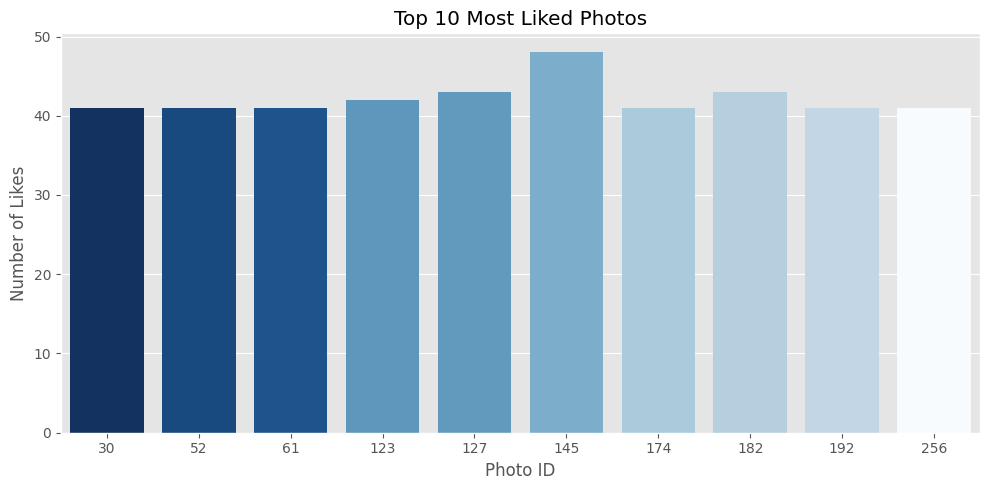

In [724]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_liked_photos,
    x="photo",
    y="Likes",
    hue="photo",
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Most Liked Photos")
plt.xlabel("Photo ID")
plt.ylabel("Number of Likes")

plt.tight_layout()
plt.show()

## Comments Analysis

The most commented photos are analyzed to evaluate audience interaction.

In [725]:
comments_per_photo = (
    comments.groupby("Photo id")
    .size()
    .reset_index(name="Comments")
)

comments_per_photo.head(10)

,Photo id,Comments
0,1,25
1,2,31
2,3,27
3,4,32
4,5,27
5,6,29
6,7,27
7,8,38
8,9,25
9,10,24


In [726]:
top_commented_photos = comments_per_photo.sort_values(
    by="Comments",
    ascending=False
).head(10)

top_commented_photos

,Photo id,Comments
12,13,39
246,247,39
156,157,39
7,8,38
145,146,37
28,29,36
142,143,36
224,225,36
129,130,35
175,176,35


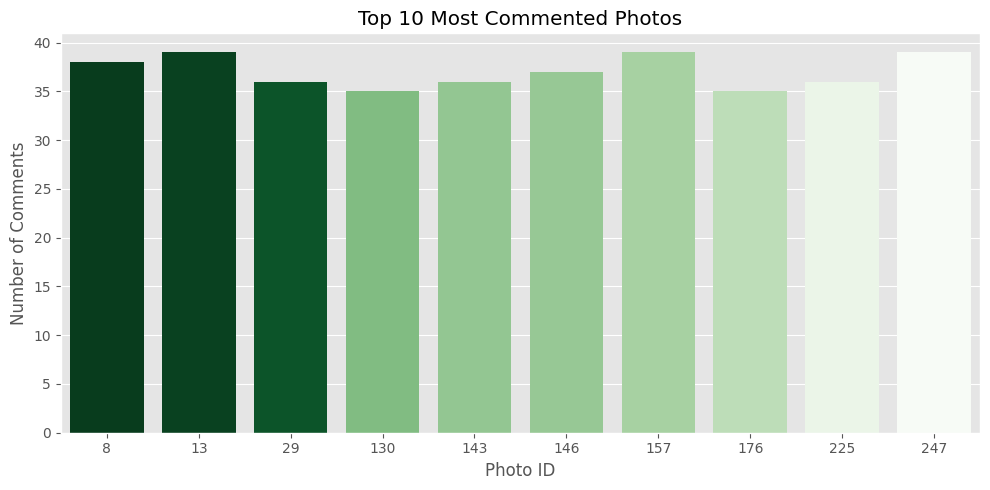

In [727]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_commented_photos,
    x="Photo id",
    y="Comments",
    hue="Photo id",
    palette="Greens_r",
    legend=False
)

plt.title("Top 10 Most Commented Photos")
plt.xlabel("Photo ID")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

## Hashtag Analysis

Frequently used hashtags are identified to understand popular content topics.

In [728]:
top_tags = (
    tags["tag text"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_tags.columns = ["Hashtag", "Frequency"]

top_tags

,Hashtag,Frequency
0,sunset,1
1,photography,1
2,sunrise,1
3,landscape,1
4,food,1
5,foodie,1
6,delicious,1
7,beauty,1
8,stunning,1
9,dreamy,1


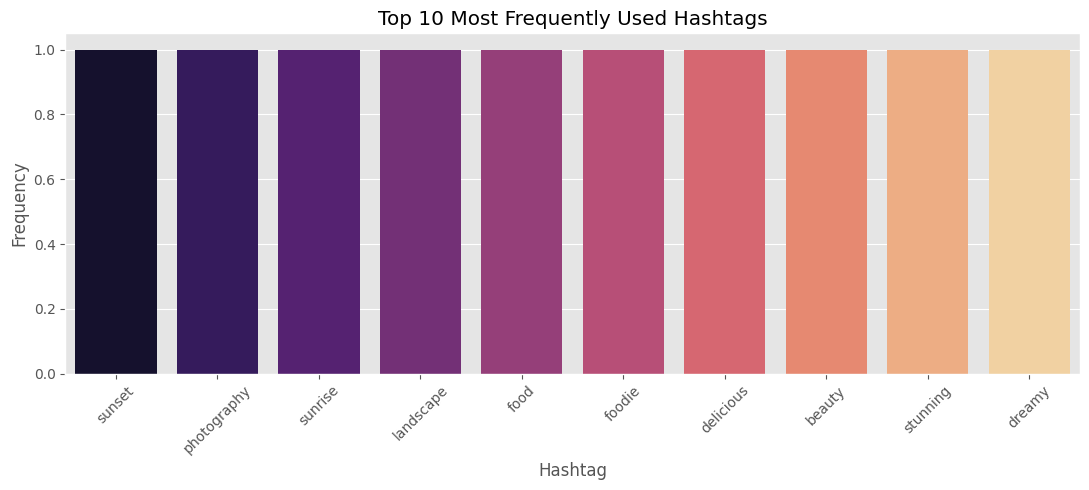

In [729]:
plt.figure(figsize=(11,5))

sns.barplot(
    data=top_tags,
    x="Hashtag",
    y="Frequency",
    hue="Hashtag",
    palette="magma",
    legend=False
)

plt.title("Top 10 Most Frequently Used Hashtags")
plt.xlabel("Hashtag")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Posting Schedule Analysis

Monthly posting activity is analyzed to identify the periods with the highest number of uploaded posts.

In [730]:
posts_by_month = (
    photos["Posting_Month"]
    .value_counts()
    .rename_axis("Posting_Month")
    .reset_index(name="Number of Posts")
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

posts_by_month["Posting_Month"] = pd.Categorical(
    posts_by_month["Posting_Month"],
    categories=month_order,
    ordered=True
)

posts_by_month = posts_by_month.sort_values("Posting_Month")

posts_by_month

,Posting_Month,Number of Posts
0,April,257


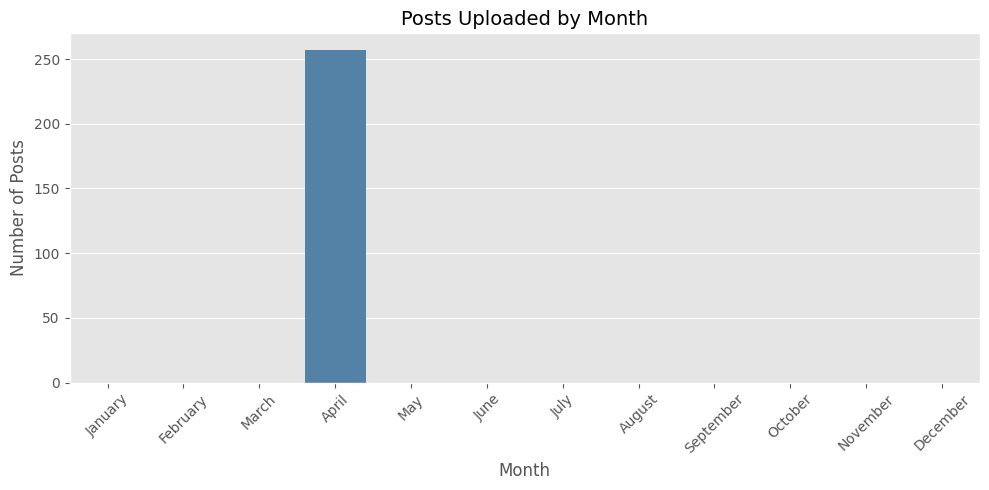

In [731]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=posts_by_month,
    x="Posting_Month",
    y="Number of Posts",
    color="steelblue"
)

plt.title("Posts Uploaded by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Public and Private Account Analysis

This section compares the distribution of public and private Instagram accounts.

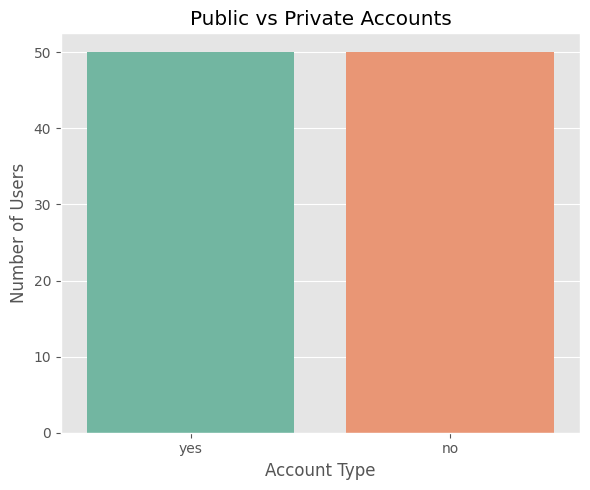

In [732]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=users,
    x="private/public",
    hue="private/public",
    palette="Set2",
    legend=False
)

plt.title("Public vs Private Accounts")
plt.xlabel("Account Type")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

## Verified Account Analysis

This section compares verified and non-verified Instagram accounts in the dataset.

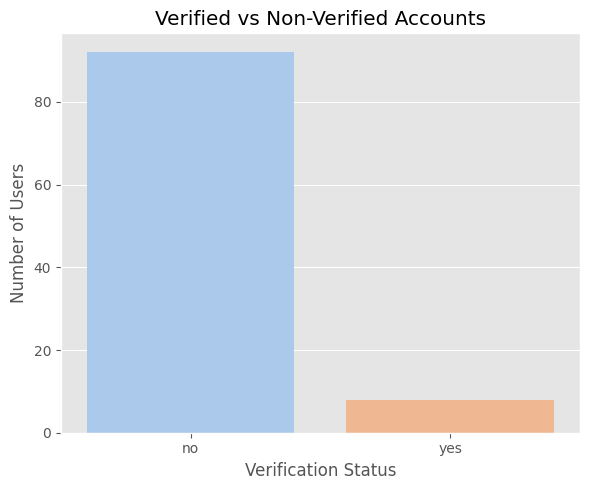

In [733]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=users,
    x="Verified status",
    hue="Verified status",
    palette="pastel",
    legend=False
)

plt.title("Verified vs Non-Verified Accounts")
plt.xlabel("Verification Status")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

# Key Findings

- April had the highest number of posts.
- Most users uploaded only a few posts.
- Popular hashtags and filters were used frequently.
- Some posts received significantly higher engagement.
- Public accounts were more common than private accounts.

# Recommendations for Alfido Tech

- Post consistently during peak activity periods.
- Use relevant hashtags and popular filters.
- Share high-quality visual content.
- Encourage user interaction through engaging captions.
- Track engagement metrics to improve future posts.

# Conclusion

This project analyzed Instagram user activity, engagement, and posting trends using Exploratory Data Analysis (EDA). The insights can help Alfido Tech improve content planning and increase audience engagement.